In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import sys

In [3]:
img = cv.imread('img/headCT.tif')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

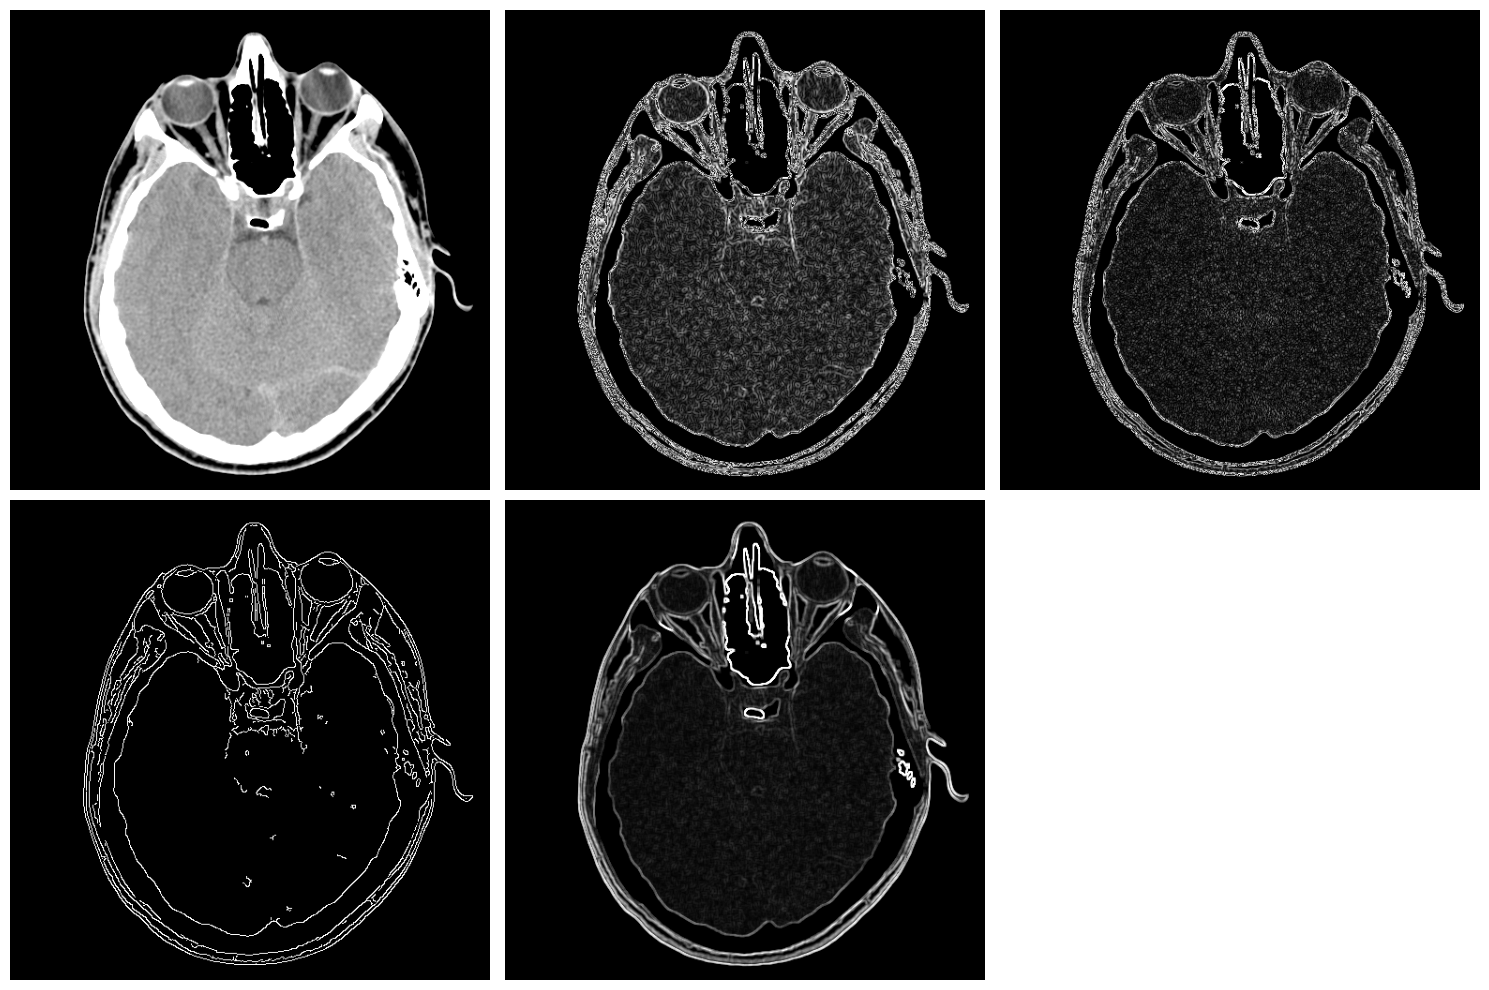

In [ ]:
# 소벨
grad_x = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
grad_y = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
sobel = cv.magnitude(grad_x, grad_y)
sobel = np.uint8(np.absolute(sobel))

# 라플라시안
laplacian = cv.Laplacian(gray, cv.CV_64F, ksize=3)
laplacian = np.uint8(np.absolute(laplacian))

# 캐니 엣지 검출
canny = cv.Canny(gray, 100, 200)

# 모폴로지 그래디언트
kernel = np.ones((3,3), np.uint8)
mg = cv.morphologyEx(gray, cv.MORPH_GRADIENT, kernel)


images = [gray, sobel, laplacian, canny, mg]


plt.figure(figsize=(15, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

- 원본    
- 소벨  
    가로 세로 방향으로 미분을 적용한 것으로    
    다른 영상에 비해 무엇가 화질이 더 떨어져 보인다.   

- 라플라시안
    소벨에 비해서 더 덜 거칠다.   
    그러나 다른 edge에 비해서 채워진 공간은 정보 유실의 우려가 있는 것 같다.   
- 캐니   
    윤곽만 남는 것이 가장 큰 특징이다.   
    비워져 이지만 확실한 경계선의 정보로 정보를 제공한다.   
    특히 잘 안보이던 중심에 조직이 어떻게 생겼는지를 가장 잘 나타내어준다.    
- 모폴로지 그래디언트    
    선이 부드럽다는 느낌이 들고     
    캐니와 함께 눈알과 눈의 경계가 잘보인다.  
    캐니에 적당한 자세함이 있는 영상 같다. 
